# Seminar 3 — One-layer perceptron (matrix derivatives) on breast cancer + MLP with sklearn
## Independent work: from formulas to code

**Goal:** solve a real binary classification task (breast cancer: malignant vs benign) twice —
first with a one-layer perceptron written *from scratch* (NumPy, matrix derivatives, like Lecture 3 §6 + §10),
then with `MLPClassifier` from sklearn — and compare.

**You will learn to:**
- load a real dataset, do EDA, split stratified, standardise;
- write sigmoid + BCE loss + **matrix** gradients and check them numerically;
- train with full-batch gradient descent, read the loss curve;
- evaluate with accuracy + confusion matrix;
- compare with `LogisticRegression` (same model!) and see what regularisation `C` does;
- tune `MLPClassifier` (hidden sizes, `alpha`) and explain when depth helps and when not.

**Notation (Lecture 3):** $z = Xw + b$, $p = \sigma(z)$, $J_{BCE} = -\frac{1}{n}\sum_i [y_i\log p_i + (1-y_i)\log(1-p_i)]$.

## 1. Theory reminder (Lecture 3 §6 + §10, read carefully)

One neuron = logistic regression. For a batch $X \in \mathbb{R}^{n \times d}$:
$$
z = Xw + b, \qquad p = \sigma(z) = \frac{1}{1+e^{-z}}, \qquad
J = -\frac{1}{n}\sum_{i=1}^n \big[y_i \log p_i + (1-y_i)\log(1-p_i)\big]
$$

Matrix backprop (one line per layer — here the net has one layer, so one line):
- $dZ = (P - y)/n$ (sigmoid + BCE collapse into a difference — proof in Lecture 3 §6);
- $dW = X^T dZ$ — shape $(d \times n)(n \times 1) \to (d \times 1)$ ✓, $db = \mathrm{mean}(dZ)$;
- gradient descent: $w := w - \alpha\, dW$, $b := b - \alpha\, db$.

**Shape rule:** gradient has the shape of its parameter. If your `dW` is not `(30,)` here — something is wrong.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("numpy:", np.__version__)

numpy: 1.21.2


## 2. Data: breast cancer (569 tumours, 30 measurements)

`load_breast_cancer`: features like mean radius / texture / perimeter (30 numbers per tumour),
target `0 = malignant`, `1 = benign`. Real data, no ground-truth weights — quality is measured on held-out test data.

In [2]:
# ---- GIVEN: load data ----
data = load_breast_cancer()
X, y = data.data, data.target
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
print("shape:", X.shape, "| features:", len(data.feature_names))
print("targets: 0 =", data.target_names[0], ", 1 =", data.target_names[1])
print(df.iloc[:, :5].describe().round(2))

shape: (569, 30) | features: 30
targets: 0 = malignant , 1 = benign
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count       569.00        569.00          569.00     569.00           569.00
mean         14.13         19.29           91.97     654.89             0.10
std           3.52          4.30           24.30     351.91             0.01
min           6.98          9.71           43.79     143.50             0.05
25%          11.70         16.17           75.17     420.30             0.09
50%          13.37         18.84           86.24     551.10             0.10
75%          15.78         21.80          104.10     782.70             0.11
max          28.11         39.28          188.50    2501.00             0.16


## 3. ✏️ Task 1 — EDA: balance + one grouped plot

1. How many malignant (0) vs benign (1)? Is the dataset balanced?
2. Plot two overlaid histograms of `mean radius`: malignant vs benign. Does this single feature already separate the classes?

malignant (0): 212  benign (1): 357


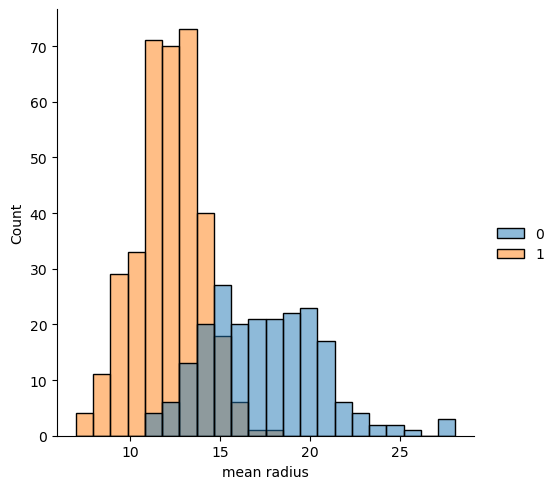

In [7]:
counts = np.bincount(y)  # <-- YOUR CODE HERE
print("malignant (0):", counts[0], " benign (1):", counts[1])  # <-- YOUR CODE HERE

sns.displot(x=df["mean radius"], hue=y);

## 4. Train / test split (stratified!)

Classes are imbalanced (212 vs 357) — `stratify=y` keeps the same ratio in train and test.
**Fit scalers and weights on train only.**

In [ ]:
# ---- GIVEN: 80/20 stratified split ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("train:", X_train.shape, y_train.shape, " test:", X_test.shape, y_test.shape)
print("train balance:", np.bincount(y_train), " test balance:", np.bincount(y_test))

## 5. ✏️ Task 2 — Standardisation (features live on wildly different scales)

Radius ~ 10, area ~ 1000 — one learning rate cannot serve both. Standardise with **train** stats:
$$
x'_j = \frac{x_j - \mu_j}{\sigma_j}, \qquad \sigma_j = 0 \to 1
$$

In [ ]:
# ✏️ TODO 2: fit/apply standardisation
def fit_standardize(X):
    """Return (mu, sigma) on X; sigma==0 -> 1."""
    ...  # <-- YOUR CODE HERE
    return mu, sigma

def apply_standardize(X, mu, sigma):
    ...  # <-- YOUR CODE HERE
    return Xs

mu_tr, sd_tr = fit_standardize(X_train)
X_train_s = apply_standardize(X_train, mu_tr, sd_tr)
X_test_s = apply_standardize(X_test, mu_tr, sd_tr)  # NB: TRAIN stats!
print("scaled train mean[:5]:", X_train_s.mean(axis=0)[:5].round(4))
print("scaled train std[:5]:", X_train_s.std(axis=0)[:5].round(4))

## 6. ✏️ Task 3 — One neuron from scratch (matrix form)

Implement exactly the §1 formulas. Shapes: `X (n,30)`, `w (30,)`, `b` scalar, `p (n,)`:
- `sigmoid(z) = 1/(1+e^{-z})` (elementwise);
- `predict_proba(X, w, b) = sigmoid(X @ w + b)`;
- `bce_loss` — scalar, clip probabilities with `eps=1e-12`;
- `compute_gradients` — returns `(dW (30,), db scalar, loss scalar)` via `dZ = (p - y)/n`.

In [ ]:
# ✏️ TODO 3: model + loss + matrix gradients
def sigmoid(z):
    ...  # <-- YOUR CODE HERE

def predict_proba(X, w, b):
    ...  # <-- YOUR CODE HERE

def bce_loss(X, y, w, b, eps=1e-12):
    ...  # <-- YOUR CODE HERE (scalar)

def compute_gradients(X, y, w, b):
    """Return (dW, db, loss). dW shape must equal w shape."""
    ...  # <-- YOUR CODE HERE
    return dW, db, loss

In [ ]:
# ---- GIVEN: numeric gradient check on 20 train points (needs Task 3) ----
Xs, ys = X_train_s[:20], y_train[:20]
w0 = rng.normal(0, 0.1, size=Xs.shape[1]); b0 = 0.1
dW, db, _ = compute_gradients(Xs, ys, w0, b0)
e = 1e-7
num_dW = np.array([(bce_loss(Xs, ys, w0 + (np.arange(w0.size) == j) * e, b0)
                    - bce_loss(Xs, ys, w0 - (np.arange(w0.size) == j) * e, b0)) / (2 * e)
                   for j in range(w0.size)])
num_db = (bce_loss(Xs, ys, w0, b0 + e) - bce_loss(Xs, ys, w0, b0 - e)) / (2 * e)
print("max |dW - numeric|:", np.max(np.abs(dW - num_dW)))
print("|db - numeric|:", abs(db - num_db))
assert np.allclose(dW, num_dW, atol=1e-6) and np.isclose(db, num_db, atol=1e-6)
print("gradient check PASSED — backprop is correct, training is safe to start")

## 7. ✏️ Task 4 — Train with gradient descent

Start at zeros, repeat 2000 times: gradients → step against them (`lr=0.5`) → record loss.
A healthy run: loss falls fast, then flattens (Lecture 2 behaviour).

In [ ]:
# ✏️ TODO 4: full-batch GD
def train_perceptron(X, y, lr=0.5, iters=2000):
    w = np.zeros(X.shape[1]); b = 0.0
    hist = []
    for it in range(iters):
        ...  # <-- YOUR CODE HERE: gradients, updates, hist.append(loss)
    return w, b, np.array(hist)

In [ ]:
# ---- GIVEN: run training, loss curve, train/test accuracy (needs Task 4) ----
w, b, hist = train_perceptron(X_train_s, y_train, lr=0.5, iters=2000)
acc_tr = float(((predict_proba(X_train_s, w, b) > 0.5) == y_train).mean())
acc_te = float(((predict_proba(X_test_s, w, b) > 0.5) == y_test).mean())
print(f"loss {hist[0]:.4f} -> {hist[-1]:.4f} | train acc {acc_tr:.4f} | test acc {acc_te:.4f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(hist)
ax.set_xlabel("step"); ax.set_ylabel("BCE loss"); ax.set_title("Loss falls fast, then flattens — stop when flat")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. ✏️ Task 5 — Evaluation: confusion matrix on test

Accuracy hides *error types*. For cancer, missing a malignant tumour (FN) is worse than a false alarm (FP).
Count on **test**: TP (pred 1, true 1), TN, FP, FN — then read the plot: where do the errors sit?

In [ ]:
# ✏️ TODO 5: confusion counts on TEST (needs trained w, b)
pred_test = (predict_proba(X_test_s, w, b) > 0.5).astype(int)
cm = {}
cm["tp"] = ...  # <-- YOUR CODE HERE
cm["tn"] = ...
cm["fp"] = ...
cm["fn"] = ...
print(cm, "| test acc:", (cm["tp"] + cm["tn"]) / len(y_test))

# ---- GIVEN: plot ----
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]], cmap="Blues")
for (i, j), v in [((0, 0), "tn"), ((0, 1), "fp"), ((1, 0), "fn"), ((1, 1), "tp")]:
    ax.text(j, i, f"{v}={cm[v]}", ha="center", va="center", fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["true 0", "true 1"])
ax.set_title("Confusion matrix (test)")
plt.tight_layout(); plt.show()

## 9. Same model from sklearn: `LogisticRegression`

One neuron **is** logistic regression — `LogisticRegression` should agree with your code.
The extra knob is `C` (inverse regularisation strength): small `C` = strong regularisation,
`C → ∞` = your unregularised loss. Watch test accuracy while `C` grows: too big → overfit.

In [ ]:
# ---- GIVEN: baseline + regularisation sweep ----
base = LogisticRegression(C=1.0, max_iter=5000).fit(X_train_s, y_train)
print(f"sklearn C=1.0: train {base.score(X_train_s, y_train):.4f} test {base.score(X_test_s, y_test):.4f}")
print(f"scratch:       train {acc_tr:.4f} test {acc_te:.4f}  <- your Task 4 numbers should match this row")

In [ ]:
# ✏️ TODO 6: sweep C, collect test accuracy
Cs = [0.01, 0.1, 1.0, 100.0, 1e6]
test_acc = []
for C in Cs:
    ...  # <-- YOUR CODE HERE: fit LogisticRegression(C=C, max_iter=5000), append test acc

# ---- GIVEN: plot ----
plt.figure(figsize=(6, 3.5))
plt.semilogx(Cs, test_acc, "o-")
plt.xlabel("C (less regularisation →)"); plt.ylabel("test accuracy")
plt.title("Too much freedom (big C) → overfit, test falls")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Multilayer perceptron with sklearn: `MLPClassifier`

Same data, now depth: `hidden_layer_sizes=(100,)` = Lecture 3 §4 architecture (30 → 100 → 1, tanh hidden).
`alpha` = L2 regularisation strength (sklearn's name for $\lambda$). `loss_curve_` shows optimisation live.
Question to carry into Task 7: does depth beat one neuron here?

In [ ]:
# ---- GIVEN: baseline MLP ----
mlp = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.0001, max_iter=3000, random_state=42)
mlp.fit(X_train_s, y_train)
print(f"MLP(100,): train {mlp.score(X_train_s, y_train):.4f} test {mlp.score(X_test_s, y_test):.4f} iters {mlp.n_iter_}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(mlp.loss_curve_)
ax.set_xlabel("step"); ax.set_ylabel("loss (BCE + L2)")
ax.set_title("MLP loss curve")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 11. ✏️ Task 7 — Tune depth and regularisation

Grid over `hidden_layer_sizes` × `alpha`, record **test** accuracy, report top-3.
Expectation check: on this almost-linearly-separable data the MLP should roughly tie one neuron, not crush it.
(Where depth crushes — see Task 8.)

In [ ]:
# ✏️ TODO 7: grid search, keep the best by TEST accuracy
results = {}
for h in [(10,), (50,), (100,), (50, 20)]:
    for a in [0.0001, 0.01]:
        ...  # <-- YOUR CODE HERE: fit MLPClassifier(hidden_layer_sizes=h, alpha=a, max_iter=3000, random_state=42), store test acc
top3 = sorted(results.items(), key=lambda kv: -kv[1])[:3]
print("top-3:", [(str(k), round(v, 4)) for k, v in top3])

In [ ]:
# ---- GIVEN: bar chart of your Task 7 grid ----
names = [f"{h}\na={a}" for (h, a) in results.keys()]
vals = list(results.values())
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(names, vals, color="teal", alpha=0.7)
ax.axhline(acc_te, color="red", linestyle="--", label=f"one neuron: {acc_te:.4f}")
ax.set_ylabel("test accuracy"); ax.set_title("MLP configs vs one neuron (red line)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 12. ✏️ Task 8 — Where depth wins: moons (bonus, ties back to Lecture 3 §1–§4)

Breast cancer is nearly linearly separable — no wonder one line almost ties an MLP.
On moons (Lecture 3 §1: one line always fails) the ranking must flip: `LogisticRegression` vs `MLPClassifier`.

In [ ]:
# ---- GIVEN: moons data ----
def make_moons(n=400, noise=0.15):
    n2 = n // 2
    t = np.linspace(0, np.pi, n2)
    outer = np.c_[np.cos(t), np.sin(t)]
    inner = np.c_[1 - np.cos(t), 0.5 - np.sin(t)]
    Xm = np.vstack([outer, inner]) + rng.normal(0, noise, size=(n, 2))
    ym = np.array([0] * n2 + [1] * n2)
    return Xm, ym

Xm, ym = make_moons()
Xmr, Xme, ymr, yme = train_test_split(Xm, ym, test_size=0.25, random_state=7, stratify=ym)
mu_m, sd_m = Xmr.mean(axis=0), Xmr.std(axis=0)
Xmr_s, Xme_s = (Xmr - mu_m) / sd_m, (Xme - mu_m) / sd_m

# ✏️ TODO 8: fit both sklearn models, print test accuracies, one-line verdict
...  # <-- YOUR CODE HERE

## Takeaways

1. One neuron + matrix gradients (`dW = XᵀdZ`, shape rule) solves breast cancer at ~0.98 test — implementable in 10 lines.
2. It **is** logistic regression: sklearn `C=1.0` matches scratch; huge `C` overfits (train 1.00, test drops) — regularisation matters on real data.
3. Always: stratify splits, standardise with train stats, read confusion matrix (FN vs FP cost differs).
4. MLP ties here (data is nearly linear) but crushes on moons — depth pays exactly where one line fails.

**Questions to check yourself:** why does `dZ = (p−y)/n` need the `/n`? What breaks without standardisation (try `train_perceptron` on raw `X_train`)? Why does the red line in §11 sit so high?